# 8. 对抗性防御算法之免费对抗性训练（1）

## 8.0 上节内容回顾与本节主要内容介绍

在上节中，我们使用5步攻击的PGD进行对抗性训练，得到了鲁棒性很好的模型。然而，这样的对抗性训练的计算资源消耗是普通训练的六倍。那么，能否在更小的计算资源消耗下获得鲁棒性呢？本节将介绍一种特殊的对抗性训练算法：免费对抗性训练。它能够在计算资源等同于标准训练的情况下获得对抗性训练的鲁棒性。

本实验的主要内容为采用Python、PyTroch等技术，实现免费对抗性训练算法，并进行鲁棒性测试。

## 8.1 免费对抗性训练介绍

免费对抗性训练<sup>[1]</sup>相较于标准训练几乎没有额外开销。简单地说，免费对抗性训练利用了模型训练过程中的反向传播来制造对抗性样本。

<div align=center>
<img src="imgs\freeat.jpg"/>
</div>

上面（图片来自[1]）展示了免费对抗性训练的算法流程。对于原本需要执行N轮的训练，免费对抗性训练只执行N/m轮训练，但是在每一轮中，针对一个批次的样本，执行m次前向和反向传播，并且在反向传播时像攻击一样更新样本，并将此样本应用到下一次的前向传播中。

参考文献：

[1] [Shafahi A, Najibi M, Ghiasi M A, et al. Adversarial training for free![J]. Advances in Neural Information Processing Systems, 2019, 32.](https://proceedings.neurips.cc/paper/2019/hash/7503cfacd12053d309b6bed5c89de212-Abstract.html)

## 8.2 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

import test; test_fn = test.test
from loss import CWLoss
from pgd import LinfPGD
from utils import load_mnist_test


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 8.3 使用免费对抗性训练进行防御

In [2]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 250        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

M = 5                   # 对每个batch连续执行M次免费对抗性训练迭代
EPS = 0.1               # 攻击步长

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

img_shape = train_dataset.data.shape[1:]

In [4]:
# 定义网络结构并统计模型参数
from models import LeNet5

cnn = LeNet5().to(device)
print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 设置Label Smoothing超参数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [5]:
"""
    免费对抗性训练实现
"""

train_accs = []    # 训练集对抗性准确率
train_losses = []  # 训练集对抗性损失

# 初始化扰动delta
delta = torch.zeros(BATCH_SIZE, 1, 28, 28).to(device)

# 训练 EPOCH / M 个轮次
for epoch in range(round(EPOCH / M)):
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = inputs.clone().detach().requires_grad_(True)
        cnn.train()

        for i in range(M):
            l_delta = delta.clone().detach().requires_grad_(True)
            
            # 前向传播
            inputs1 = inputs + l_delta
            inputs2 = torch.clamp(inputs1, min=0, max=1)

            outputs = cnn(inputs2)
            loss = loss_function(outputs, labels)
            
            # 梯度清零
            optimizer.zero_grad()
      
            # 反向传播
            loss.backward()
            
            # 参数更新
            optimizer.step()
            
            # delta更新
            # 此处grad乘以batch大小是因为攻击应该使用sum作为loss function的reduction
            delta = (delta + EPS * torch.sign(n *
                        l_delta.grad)).clamp_(-EPS, EPS)

            # 数据统计
            pred = outputs.argmax(dim=-1)
            
            train_total += n
            train_correct += (pred == labels).sum().item()
            train_loss += loss.data.item() * n  

    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, training loss: {train_loss / train_total:.7f}, '
                f'training acc: {100 * train_correct / train_total:.2f}%')

 12836 20260207 14:49:57 training epoch: 0, training loss: 0.2636858, training acc: 91.33%
 12836 20260207 14:50:49 training epoch: 1, training loss: 0.1113289, training acc: 96.37%
 12836 20260207 14:51:23 training epoch: 2, training loss: 0.0895439, training acc: 97.07%
 12836 20260207 14:51:58 training epoch: 3, training loss: 0.0760601, training acc: 97.48%
 12836 20260207 14:52:33 training epoch: 4, training loss: 0.0701230, training acc: 97.69%
 12836 20260207 14:53:07 training epoch: 5, training loss: 0.0605742, training acc: 97.93%
 12836 20260207 14:53:39 training epoch: 6, training loss: 0.0556628, training acc: 98.13%
 12836 20260207 14:54:12 training epoch: 7, training loss: 0.0506615, training acc: 98.26%
 12836 20260207 14:54:45 training epoch: 8, training loss: 0.0471948, training acc: 98.34%
 12836 20260207 14:55:19 training epoch: 9, training loss: 0.0431016, training acc: 98.54%


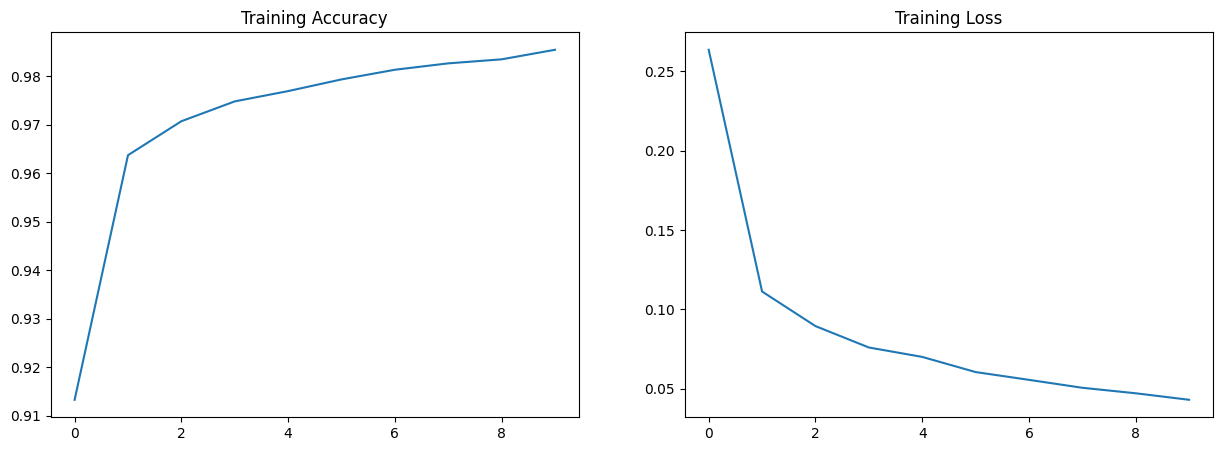

In [6]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(round(EPOCH / M))]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs)
plt.title('Training Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses)
plt.title('Training Loss')

plt.show()

In [7]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_Free_AT_5.pth')

## 8.4 鲁棒性测试

### 8.4.0 白盒攻击测试

In [8]:
# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 加载样本
imgs, lbls = load_mnist_test()

# 执行测试
cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')                         # 干净样本
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'FreeAT - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

 12836 20260207 14:55:49 FreeAT - Clean: 98.90, FGSM: 93.30, PGD: 88.48, CW: 89.04


### 8.4.1 迁移攻击测试

In [9]:
# 模型加载
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义攻击参数
FGSM_kwargs = dict(net=std_lenet, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'Transfer Attack - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}')

 12836 20260207 14:56:16 Transfer Attack - FGSM: 97.83, PGD: 97.88, CW: 98.63


由此结果可知，迁移攻击难以有效地攻击Free-AT模型。

### 8.4.2 AutoAttack测试

In [10]:
from autoattack import AutoAttack

adversary = AutoAttack(cnn, eps=0.1)

x_adv = adversary.run_standard_evaluation(imgs, lbls)

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 98.90%
apgd-ce - 1/40 - 34 out of 250 successfully perturbed
apgd-ce - 2/40 - 29 out of 250 successfully perturbed
apgd-ce - 3/40 - 27 out of 250 successfully perturbed
apgd-ce - 4/40 - 29 out of 250 successfully perturbed
apgd-ce - 5/40 - 45 out of 250 successfully perturbed
apgd-ce - 6/40 - 32 out of 250 successfully perturbed
apgd-ce - 7/40 - 30 out of 250 successfully perturbed
apgd-ce - 8/40 - 22 out of 250 successfully perturbed
apgd-ce - 9/40 - 27 out of 250 successfully perturbed
apgd-ce - 10/40 - 29 out of 250 successfully perturbed
apgd-ce - 11/40 - 24 out of 250 successfully perturbed
apgd-ce - 12/40 - 34 out of 250 successfully perturbed
apgd-ce - 13/40 - 30 out of 250 successfully perturbed
apgd-ce - 14/40 - 27 out of 250 successfully perturbed
apgd-ce - 15/40 - 29 out of 250 successfully perturbed
apgd-ce - 16/40 - 27 out of 250 successfully perturbed

与使用PGD5进行对抗性训练相比较：

| 模型 | Clean | FGSM | PGD20 | CW20 | AutoAttack |
|:----:|:-----:|:----:|:------:|:-----:|:----------:|
|PGD5-AT|99.06|96.24|95.26|95.17|95.02|
|Free-AT|99.17|94.37|91.70|91.81|90.97|



结果显示，免费对抗性训练在几乎没有额外计算开销的情况下达到了与对抗性训练相当的鲁棒性。